# Advanced Many-To-Many Relationships

You have now learned the design blocks used in relational databases. Sometimes, however, thees building blocks have to be "tweaked" a bit to achieve a desired goal. This chapter is dedicated to exploring a very useful variation on the many-to-many relationship.

# Many-To-Many Relationships with Additional Data

In this section you are going to add the RetroFun ordering subsystem to the database, which includes customers and orders. The next diagram shows how the new tables and relationships fit in the existing database.

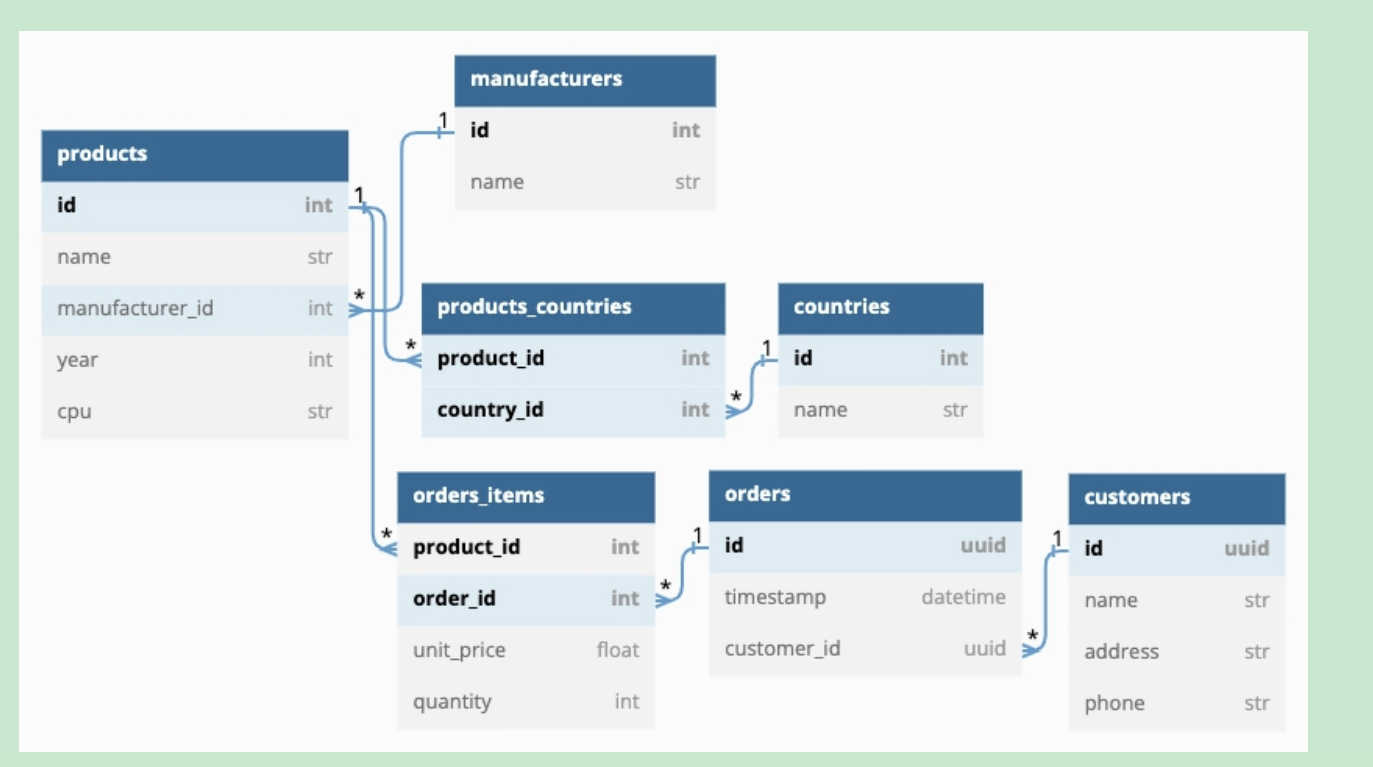

The new customers and orders tables have a one-to-many relationship between them, with customers on the "one" side. The products and orders tables have a many-to-many relationship, with the orders_items table as the join table. But the join table in this relationship has additional columns besides the two foreign keys.

This join table in this relationship effectively represents each line item in an order, with references to the order and the product. But this isn't sufficient, the relationship also needs to define a quantity and a unit price for the sale. 

Having additional data in the join table complicates things. The many-to-many relationship between products and countries did not have any extra columns, and that allowed SQLAlchemy to take full control to insert or delete entries from this table as needed. When there are additional columns, how would SQLAlchemy know what to write in those extra columns when it needs to insert a new item?

Many-to-many relationships with extra columns in the join table need to use a less automatic workflow with SQLAlchemy, because the application has to provide values for the additional columns that are part of the relationship when two entities are linked.



AS a first step to implement orders for RetroFun, the application can be expanded with the Customer and Order models, and a one-to-many relationship between them. These are added at the bottom of _models.py_

```python
# %load models.py
from datetime import datetime
from typing import Optional
from uuid import UUID, uuid4
from sqlalchemy import String, Text, ForeignKey, Table, Column
from sqlalchemy.orm import Mapped, WriteOnlyMapped, mapped_column, relationship
from db import Model


ProductCountry = Table(
    'products_countries',
    Model.metadata,
    Column('product_id', ForeignKey('products.id'), primary_key=True,
           nullable=False),
    Column('country_id', ForeignKey('countries.id'), primary_key=True,
           nullable=False),
)


class Product(Model):
    __tablename__ = 'products'

    id: Mapped[int] = mapped_column(primary_key=True)
    name: Mapped[str] = mapped_column(String(64), index=True, unique=True)
    manufacturer_id: Mapped[int] = mapped_column(
        ForeignKey('manufacturers.id'), index=True)
    year: Mapped[int] = mapped_column(index=True)
    cpu: Mapped[Optional[str]] = mapped_column(String(32))

    manufacturer: Mapped['Manufacturer'] = relationship(
        back_populates='products')
    countries: Mapped[list['Country']] = relationship(
        secondary=ProductCountry, back_populates='products')
    order_items: WriteOnlyMapped['OrderItem'] = relationship(
        back_populates='product')
    reviews: WriteOnlyMapped['ProductReview'] = relationship(
        back_populates='product')

    def __repr__(self):
        return f'Product({self.id}, "{self.name}")'


class Manufacturer(Model):
    __tablename__ = 'manufacturers'

    id: Mapped[int] = mapped_column(primary_key=True)
    name: Mapped[str] = mapped_column(String(64), index=True, unique=True)

    products: Mapped[list['Product']] = relationship(
        cascade='all, delete-orphan', back_populates='manufacturer')

    def __repr__(self):
        return f'Manufacturer({self.id}, "{self.name}")'


class Country(Model):
    __tablename__ = 'countries'

    id: Mapped[int] = mapped_column(primary_key=True)
    name: Mapped[str] = mapped_column(String(32), index=True, unique=True)

    products: Mapped[list['Product']] = relationship(
        secondary=ProductCountry, back_populates='countries')

    def __repr__(self):
        return f'Country({self.id}, "{self.name}")'


class Order(Model):
    __tablename__ = 'orders'

    id: Mapped[UUID] = mapped_column(default=uuid4, primary_key=True)
    timestamp: Mapped[datetime] = mapped_column(default=datetime.utcnow,
                                                index=True)
    customer_id: Mapped[UUID] = mapped_column(ForeignKey('customers.id'),
                                              index=True)

    customer: Mapped['Customer'] = relationship(back_populates='orders')
    order_items: Mapped[list['OrderItem']] = relationship(
        back_populates='order')

    def __repr__(self):
        return f'Order({self.id.hex})'


class Customer(Model):
    __tablename__ = 'customers'

    id: Mapped[UUID] = mapped_column(default=uuid4, primary_key=True)
    name: Mapped[str] = mapped_column(String(64), index=True, unique=True)
    address: Mapped[Optional[str]] = mapped_column(String(128))
    phone: Mapped[Optional[str]] = mapped_column(String(32))

    orders: WriteOnlyMapped['Order'] = relationship(back_populates='customer')
    product_reviews: WriteOnlyMapped['ProductReview'] = relationship(
        back_populates='customer')

    def __repr__(self):
        return f'Customer({self.id.hex}, "{self.name}")'


class OrderItem(Model):
    __tablename__ = 'orders_items'

    product_id: Mapped[int] = mapped_column(ForeignKey('products.id'),
                                            primary_key=True)
    order_id: Mapped[UUID] = mapped_column(ForeignKey('orders.id'),
                                           primary_key=True)
    unit_price: Mapped[float]
    quantity: Mapped[int]

    product: Mapped['Product'] = relationship(back_populates='order_items')
    order: Mapped['Order'] = relationship(back_populates='order_items')


class ProductReview(Model):
    __tablename__ = 'product_reviews'

    product_id: Mapped[int] = mapped_column(ForeignKey('products.id'),
                                            primary_key=True)
    customer_id: Mapped[UUID] = mapped_column(ForeignKey('customers.id'),
                                              primary_key=True)
    timestamp: Mapped[datetime] = mapped_column(default=datetime.utcnow,
                                                index=True)
    rating: Mapped[int]
    comment: Mapped[Optional[str]] = mapped_column(Text)

    product: Mapped['Product'] = relationship(back_populates='reviews')
    customer: Mapped['Customer'] = relationship(
        back_populates='product_reviews')
```

There are a few new things in these models. The following sections cover them one by one.

# UUID Primary Keys

The most important difference in these two new models is that their id columns are defined with the UUID type instead of the int keys used in all the prevous models.

Note

Support for the UUID type was introduced in SQLAlchemy 2.0. The [documentation](https://docs.sqlalchemy.org/en/21/core/custom_types.html#backend-agnostic-guid-type) includes an implementation of a custom UUID type that can be used with older releases.

The problem with the auto-incrementing integer primary keys used earlier is that when they are inlucded in URLs or emails, they indirectly allow people to estimate the size of the database tables they reference. Most business will probably prefer to keep the number of customers or orders they have private, so using integer keys for these tables is not a good idea.

A way to avoid giving away this type of information is to switch away from numeric primary keys. The new models define id as [UUID](https://en.wikipedia.org/wiki/Universally_unique_identifier), which is a 16 byte binary sequence. There are several types of UUIDs and one in particular, called [UUID4](https://en.wikipedia.org/wiki/Universally_unique_identifier#Version_4_(random)), is a good choice for primary keys. In case you are not familiar with UUID4 support in Python, the following Python session shows how to generate them and print them:

In [1]:
from uuid import uuid4
id = uuid4()
id.bytes

b'\xa3J\xee\xa6\xac\x1aBR\xa7?\x08\r\xfcK\xfe\xb8'

In [2]:
id.hex

'a34aeea6ac1a4252a73f080dfc4bfeb8'

Unfortunately SQLAlchemy can only manage integer primary keys automatically. To avoid having to remember to create and assign a UUID4 to each new Order or Customer instance that is added, the id columns in these two models are given a default argument, which automatically assigns values to them if the application doesn't. The default argument can be set to a constant value or to a callable, such as a function. If it is set to a callable, SQLALchemy will call it every time it needs to give a default value to a column. The id columns above pass the uuid4 function as default, so taht each new item gets its own newly generated UUID4. When passing functions as default column values it is important to remember to not include the () after the function name. SQLALchemy needs the reference to the function itself, so that it can call it when a value needs to be generated. 

The __repr__() methods in both classes use the hex attribute of the UUID object to decode the binary UUID4 into a printable hexadecimal string for debugging.

The one-to-many relationship between customers and orders is established by adding a foreign key on the "many" side, which in this case is the Order model. this is the customer_id column, which is also give a UUID type to match the type of Customer.id



# Date and Time Columns

The Order model features a timestamp column decalred with a datetime type. In the same way as with the UUID type, SQLAlchemy automatically maps Python datetime objects to the appropriate type in the database.

The timestamp column also has a default argument. Passing datetime.utcnow as a default will make SQLAlchemy call datetime.utcnow() each time a new order is added to the database. This effectively means that the timestamp column can be left unassigned when adding an order, and the current date and time will be automatically set during the commit operation. Once again the () are not included in the default argument so that SQLAlchemy receives a reference to the function, without calling it. 

When working with date and time values in a database it is important to maintain a uniform timezone. The most sane approach is to store all timestamps in the UTC timezone, and for that reason the default is set to utcnow instead of now. The application can convert UTC timestamps retrieved from the database to the timezone of the client when they are presented to the user. For applications this is often done in the web browser, which has access to the user's timezone.


# Write-Only Relationships

The relationship attributes on these models are configured similarly to the relationship between manufactureres and products. The Order.customer relationship uses the default lazy evaluation, but the Customer.orders relationship has a new definition:

```python
orders: WriteOnlyMapped['Order'] = relationshp(back_populates='customer')
```

The WriteOnlyMapped typing hint is used here to define a relationshp configured with the lazy='write_only' option. When typing isn't used or desired, the lazy argument can be given in the relationship() call.

Why is this relationship different? In general, lazy evaluation of relationships makes sense only in certain cases. Relationships that load a "one" side, such as Order.customer that may only be causually used aer perfect to evaluate lazily, and so are those that are expected to have a short number of elements, such as the Product.countries relationship from the previous chapter.

The reason why Customer.orders is defined as a write_only relationship is that a lazily evaluated one isn't very useful for it. This could potentially be a long relationship for repeat customers, and getting the entire collection of orders from a customer as a list is unlikely to be very useful. What would work for this relationship is to have a way to request only some of the customer orders, such as the most recent one, or the orders made in the last month. But a lazily loaded relationship does not provide a way to define any filters that can configure a range of elements to retreive.

What make the write_only loader convenient is that it does not attempt to load the relationship, it just generates a query object that you can execute yourself, possibly after adding filters, sorting or any other option you may need. The relationship object also has add(), add_all() and remove() methods that can be used to add or remove elements from the relationship.


How does a write_only relationship work in practice? You will see this relationshp in action later in this chapter. 

# Association Object Pattern

The next step is to create the many-to-many relationship between the Order and Product models, which will define the contents of each order. For a simple many-to-many relationship with extra columns the join table can be created as a Table instance and given to SQLAlchemy to manage. Because this relationship needs extra data, the join table is created as a Model subclass, to allow the application to manage the additional columns. SQLAlchemy calls this alternative method to define a many-to-many relationship the [Association Object Pattern](https://docs.sqlalchemy.org/en/21/orm/basic_relationships.html#association-object)



The primary key of the OrderItem model is made up of the two foreign key columns, similar to what was done in the simpler many-to-many relationship of the previous chapter. By not having the Optional typing hint, both keys are required (non-nullable in database jargon), which means that if a product or an order are deleted, any entries in this table referencing the deleted item must be removed. The model class has two additional columns to store the unit price and quantity of the ordered product, which are necessary to have all the information associated with the purchase.

Now comes the interesting part. The simpler many-to-many relationship between products and countries used the secondary argument to relationship on both models, and this was enough for SQLAlchemy to know what to do. Unfortunately, secondary cannot be used in this case because the application cannot give up control of the join table because of the extra columns.

The solution that makes this work can be derived from the fact that a many-to-many relationship can be thought of as two one-to-many relationships, or more accurately, as a one-to-many relationship between the first model and the join table, and a many-to-one relationship between the join table and the second model. It turns out that if you think about the two halves of this relationship separately, then there is no need to rely on the secondary argument.



The result is that four relationshp attributes are added, two for each one-to-many half of the many-to-many relationship. 


# A New Database Migration

Now that the changes that implement customers and orders in _models.py_ are complete, it is time to migrate the database, so that it receives these changes. Create a second 


╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌
 Plan: Reset Chapter5 Alembic to Match Chapter4

 Goal

 Reset the alembic setup in chapter5 to match chapter4's state, so you can
  practice creating migrations yourself as you work through the textbook.

 Steps

 1. Remove existing alembic files from chapter5

 rm -rf chapter5/migrations
 rm chapter5/alembic.ini

 2. Copy alembic files AND database from chapter4 to chapter5

 cp chapter4/alembic.ini chapter5/
 cp -r chapter4/migrations chapter5/
 cp chapter4/retrofun.sqlite chapter5/

 This copies:
 - alembic.ini - alembic configuration
 - migrations/ - including the first migration and env.py
 - retrofun.sqlite - the database with the initial tables AND the
 alembic_version tracking table

 3. Update the database connection (if needed)

 - The copied alembic.ini may need its sqlalchemy.url updated
 - Or your env.py may read from environment variables/config file

 4. Practice creating new migrations

 As you work through chapter5, you can now run:
 cd chapter5
 alembic revision --autogenerate -m "customers_and_orders"

 Verification

 After copying:
 - chapter5/migrations/versions/ should contain only 1 migration file (the
  products/manufacturers/countries one)
 - Running alembic history in chapter5 should show only that single
 migration

 Note

 The migration revision IDs will be different between chapters (chapter4
 uses b5be12e2ab48, chapter5's original used 12a276751a76), but that's
 fine since each chapter operates independently.